# Olist E-Commerce Analysis

## Business Context

This project analyzes the Olist Brazilian e-commerce dataset to understand
customer satisfaction, order value, delivery performance, product categories,
and payment behavior.

The analysis focuses on identifying relationships between operational
performance and customer experience, and translating statistical findings
into actionable business insights.

## Objectives

- Analyze order value and delivery performance
- Explore product category and payment behavior
- Investigate the relationship between delivery time and customer satisfaction
- Evaluate differences between product categories using statistical tests
- Examine the relationship between payment methods and order outcomes
- Translate analytical findings into business recommendations

## Analytical Approach

The project follows an end-to-end analytical workflow:

**Data Preparation → Exploratory Data Analysis → Relationship Analysis → Statistical Testing → Business Insights**

## 1. Dataset Overview

The Olist dataset consists of multiple relational tables connected through
unique identifiers such as `order_id`, `customer_id`, `product_id`, and `seller_id`.

The analysis uses the following datasets:

| Dataset | Purpose |
|---|---|
| Customers | Customer information and geographic data |
| Orders | Order status and purchase/delivery timestamps |
| Order Items | Products, prices, freight values, and sellers |
| Payments | Payment methods, installments, and payment values |
| Reviews | Customer review scores and review information |
| Products | Product attributes and categories |
| Sellers | Seller information and geographic data |

These tables are combined according to the analytical question rather than
merged indiscriminately. This helps preserve the correct level of analysis
and prevents duplicate records from distorting the results.


### 1.1. Libraries

The following Python libraries are used throughout the analysis for data manipulation, numerical computations, and interactive data visualization.

- **Pandas:** Data loading, cleaning, transformation, and analysis
- **NumPy:** Numerical computations and statistical operations
- **Plotly Express:** Interactive data visualization

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

### 1.2 Dataset Loading


In [4]:
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")

In [5]:
datasets = {
    "Customers": customers,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers
}

dataset_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

dataset_summary

,Dataset,Rows,Columns
0,Customers,99441,5
1,Order Items,112650,7
2,Payments,103886,5
3,Reviews,99224,7
4,Orders,99441,8
5,Products,32951,9
6,Sellers,3095,4


### 1.3 Data Structure & Data Quality

Before analysis, the structure and data quality of each dataset were reviewed. This includes checking data types, missing values, and the overall completeness of the tables.

The checks were performed at the individual dataset level to preserve the relational structure of the Olist data.

In [6]:
quality_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isna().sum().sum() for df in datasets.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})

quality_summary

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,99441,5,0,0
1,Order Items,112650,7,0,0
2,Payments,103886,5,0,0
3,Reviews,99224,7,145903,0
4,Orders,99441,8,4908,0
5,Products,32951,9,2448,0
6,Sellers,3095,4,0,0


In [7]:
missing_summary = pd.concat(
    [
        df.isna().sum().rename(dataset)
        for dataset, df in datasets.items()
    ],
    axis=1
).fillna(0).astype(int)

missing_summary

,Customers,Order Items,Payments,Reviews,Orders,Products,Sellers
customer_id,0,0,0,0,0,0,0
customer_unique_id,0,0,0,0,0,0,0
customer_zip_code_prefix,0,0,0,0,0,0,0
customer_city,0,0,0,0,0,0,0
customer_state,0,0,0,0,0,0,0
order_id,0,0,0,0,0,0,0
order_item_id,0,0,0,0,0,0,0
product_id,0,0,0,0,0,0,0
seller_id,0,0,0,0,0,0,0
shipping_limit_date,0,0,0,0,0,0,0


### Data Quality Findings

The data quality check identified missing values in three datasets: Reviews, Orders, and Products.

- **Reviews:** Missing values are concentrated in `review_comment_title` and `review_comment_message`. Since review scores and review timestamps are available, these missing values represent absent written comments rather than missing review records.
- **Orders:** Missing values occur mainly in delivery-related timestamps, including carrier delivery and customer delivery dates. These fields are relevant to the delivery performance analysis and will therefore be handled carefully rather than imputed arbitrarily.
- **Products:** Missing values are mainly found in product category, description, photo count, and physical dimension attributes. Product category completeness will be considered when conducting category-level analyses.
- **Customers, Order Items, Payments, and Sellers:** No missing values were detected.
- **Duplicate rows:** No duplicate records were detected across the datasets.

Missing values will not be automatically filled at this stage. Each field will be evaluated according to its analytical purpose before any cleaning decision is made.

## 2. Exploratory Data Analysis

This section explores the main characteristics of the Olist e-commerce business, with a focus on order value, delivery performance, product categories, payment behavior, and customer satisfaction.

The analysis is conducted at the appropriate level of aggregation for each business question to avoid misleading results caused by duplicated order-level records.

### 2.1 Date Preparation

Several business metrics in this analysis depend on accurate time calculations. Date-related fields are therefore converted to datetime format before calculating delivery duration and other time-based metrics.

In [8]:
# Convert date columns to datetime format

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

In [9]:
orders[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


### 2.2 Building the Order-Level Analytical Dataset

The original Olist data is stored across multiple relational tables, and some tables contain multiple records per order.

To preserve the correct unit of analysis, order-level metrics are aggregated before combining the datasets. This prevents duplicate order records from distorting business metrics such as order value, delivery time, and customer satisfaction.

In [10]:
# Aggregate order items to the order level

order_items_summary = (
    order_items
    .groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

order_items_summary["order_value"] = (
    order_items_summary["product_value"]
    + order_items_summary["freight_value"]
)

order_items_summary.head()

,order_id,item_count,product_value,freight_value,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,218.04


In [11]:
# Aggregate payments to the order level

payments_summary = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max")
    )
    .reset_index()
)

payments_summary.head()

,order_id,payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3


In [12]:
# Aggregate reviews to the order level

reviews_summary = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean")
    )
    .reset_index()
)

reviews_summary.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [13]:
# Build the order-level analytical dataset

order_analysis = (
    orders
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
    .merge(
        order_items_summary,
        on="order_id",
        how="left"
    )
    .merge(
        payments_summary,
        on="order_id",
        how="left"
    )
    .merge(
        reviews_summary,
        on="order_id",
        how="left"
    )
)

order_analysis.shape

(99441, 16)

In [14]:
# Check whether each order appears only once

order_analysis["order_id"].nunique(), len(order_analysis)

(99441, 99441)

In [15]:
# Create delivery performance metrics

order_analysis["delivery_days"] = (
    order_analysis["order_delivered_customer_date"]
    - order_analysis["order_purchase_timestamp"]
).dt.days

order_analysis["delivery_delay_days"] = (
    order_analysis["order_delivered_customer_date"]
    - order_analysis["order_estimated_delivery_date"]
).dt.days

order_analysis["on_time_delivery"] = (
    order_analysis["delivery_delay_days"] <= 0
)

order_analysis[
    [
        "order_id",
        "order_value",
        "delivery_days",
        "delivery_delay_days",
        "on_time_delivery",
        "review_score"
    ]
].head()

,order_id,order_value,delivery_days,delivery_delay_days,on_time_delivery,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,8.0,-8.0,True,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,13.0,-6.0,True,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,9.0,-18.0,True,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,13.0,-13.0,True,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,2.0,-10.0,True,5.0


In [16]:
# Check missing delivery dates and on-time delivery classification

order_analysis[
    [
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "delivery_delay_days",
        "on_time_delivery"
    ]
].isna().sum()

,0
order_delivered_customer_date,2965
order_estimated_delivery_date,0
delivery_days,2965
delivery_delay_days,2965
on_time_delivery,0


## 3. Descriptive Statistics

This section summarizes the main characteristics of the Olist marketplace data at the order level. The analysis focuses on order value, product quantity, freight costs, customer reviews, and delivery performance.

In [17]:
# Basic order-level statistics

order_summary = pd.Series({
    "Total Orders": len(order_analysis),
    "Total Order Value": order_analysis["order_value"].sum(),
    "Average Order Value": order_analysis["order_value"].mean(),
    "Median Order Value": order_analysis["order_value"].median(),
    "Average Items per Order": order_analysis["item_count"].mean(),
    "Average Freight Value": order_analysis["freight_value"].mean(),
    "Average Review Score": order_analysis["review_score"].mean()
})

order_summary

,0
Total Orders,9.944100e+04
Total Order Value,1.584355e+07
Average Order Value,1.605776e+02
Median Order Value,1.052900e+02
Average Items per Order,1.141731e+00
Average Freight Value,2.282356e+01
Average Review Score,4.086793e+00


### 3.1 Order Value Analysis

Order value distribution is examined to understand the typical spending level and the presence of unusually high-value orders.

In [18]:
# Descriptive statistics for order value

order_analysis["order_value"].describe()

,order_value
count,98666.000000
mean,160.577638
std,220.466087
min,9.590000
25%,61.980000
50%,105.290000
75%,176.870000
max,13664.080000


In [19]:
# Check missing values in the main order-level metrics

order_analysis[
    [
        "order_value",
        "item_count",
        "product_value",
        "freight_value",
        "payment_value",
        "review_score"
    ]
].isna().sum()

,0
order_value,775
item_count,775
product_value,775
freight_value,775
payment_value,1
review_score,768


In [20]:
# Investigate orders with missing item-level information

order_analysis[
    order_analysis["item_count"].isna()
]["order_status"].value_counts()

,count
order_status,
unavailable,603
canceled,164
created,5
invoiced,2
shipped,1


### Handling Missing Order-Level Values

A total of 775 orders have no matching order-item records. Most of these orders are classified as `unavailable` (603) or `canceled` (164).

Because the absence of item-level records does not necessarily indicate zero product value, these missing values are not imputed as zero. Orders with unavailable order-level metrics will be excluded only from analyses that require those specific metrics.

In [21]:
# Calculate the share of orders with available order values

order_value_coverage = (
    order_analysis["order_value"].notna().mean() * 100
)

order_value_coverage

np.float64(99.22064339658692)

In [22]:
  # Compare mean and median order values

order_value_comparison = pd.Series({
    "Mean Order Value": order_analysis["order_value"].mean(),
    "Median Order Value": order_analysis["order_value"].median(),
    "Mean - Median Difference": (
        order_analysis["order_value"].mean()
        - order_analysis["order_value"].median()
    )
})

order_value_comparison

,0
Mean Order Value,160.577638
Median Order Value,105.290000
Mean - Median Difference,55.287638


In [23]:
# Identify high-value orders using the IQR method

q1 = order_analysis["order_value"].quantile(0.25)
q3 = order_analysis["order_value"].quantile(0.75)

iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

high_value_orders = order_analysis[
    order_analysis["order_value"] > upper_bound
]

print("Upper Bound:", upper_bound)
print("High-Value Orders:", len(high_value_orders))
print("Share of Orders (%):", len(high_value_orders) / len(order_analysis) * 100)

Upper Bound: 349.20500000000004
High-Value Orders: 7775
Share of Orders (%): 7.818706569724762


In [24]:
# Measure the contribution of high-value orders to total order value

high_value_share = (
    high_value_orders["order_value"].sum()
    / order_analysis["order_value"].sum()
    * 100
)

high_value_share

np.float64(33.874265884058715)

**Findings**

The order value distribution is right-skewed, with the mean order value (160.58) notably higher than the median (105.29).

Using the IQR method, 7,775 orders (7.82% of all orders) were identified as high-value orders with an order value above 349.21.

Although these orders represent only 7.82% of all orders, they account for 33.87% of the total order value. This indicates that a relatively small group of high-value orders contributes substantially to overall sales value.

### 3.2 Order Size Analysis

Order size is examined to understand how many items customers typically purchase per order and whether larger baskets are associated with higher order values.

In [25]:
# Descriptive statistics for items per order

order_analysis["item_count"].describe()

,item_count
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


In [26]:
# Calculate the share of single-item orders

single_item_share = (
    (order_analysis["item_count"] == 1).mean() * 100
)

single_item_share

np.float64(89.3625365794793)

In [27]:
# Compare order value by basket size

basket_size_analysis = (
    order_analysis
    .dropna(subset=["item_count", "order_value"])
    .groupby("item_count")
    .agg(
        order_count=("order_id", "count"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

basket_size_analysis.head(10)

,item_count,order_count,average_order_value
0,1.0,88863,150.746033
1,2.0,7516,212.307173
2,3.0,1322,292.735696
3,4.0,505,391.661604
4,5.0,204,473.365441
5,6.0,198,531.515152
6,7.0,22,611.453636
7,8.0,8,2304.925000
8,9.0,3,1092.240000
9,10.0,8,1687.460000


In [28]:
# Measure the relationship between basket size and order value

basket_size_correlation = (
    order_analysis[["item_count", "order_value"]]
    .corr()
    .loc["item_count", "order_value"]
)

basket_size_correlation

np.float64(0.18915458937976506)

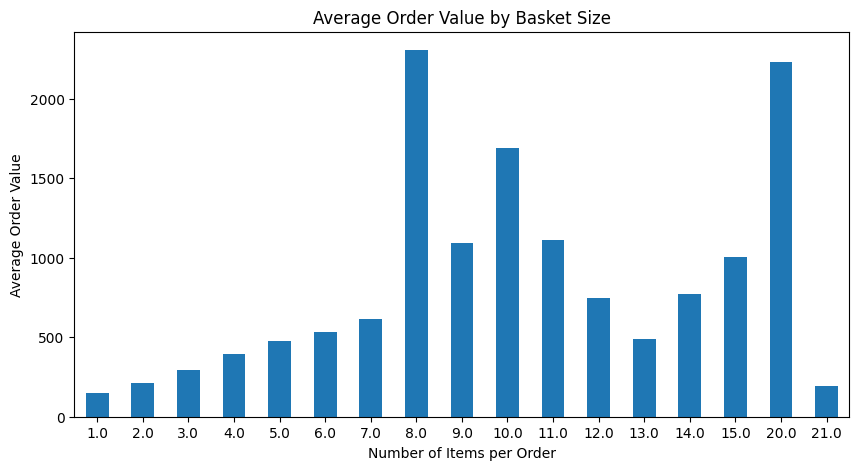

In [29]:
# Visualize average order value by basket size

import matplotlib.pyplot as plt

basket_size_analysis.plot(
    x="item_count",
    y="average_order_value",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Average Order Value by Basket Size")
plt.xlabel("Number of Items per Order")
plt.ylabel("Average Order Value")
plt.xticks(rotation=0)
plt.show()

In [30]:
# Focus on common basket sizes

common_basket_sizes = basket_size_analysis[
    basket_size_analysis["item_count"] <= 6
]

common_basket_sizes

,item_count,order_count,average_order_value
0,1.0,88863,150.746033
1,2.0,7516,212.307173
2,3.0,1322,292.735696
3,4.0,505,391.661604
4,5.0,204,473.365441
5,6.0,198,531.515152


In [31]:
# Compare single-item orders with larger baskets

single_item_orders = basket_size_analysis[
    basket_size_analysis["item_count"] == 1
]["order_count"].iloc[0]

larger_basket_orders = basket_size_analysis[
    basket_size_analysis["item_count"] >= 2
]["order_count"].sum()

larger_basket_share = (
    larger_basket_orders /
    (single_item_orders + larger_basket_orders)
) * 100

print("Single-item orders:", single_item_orders)
print("Orders with 2+ items:", larger_basket_orders)
print("Share of orders with 2+ items (%):", larger_basket_share)

Single-item orders: 88863
Orders with 2+ items: 9803
Share of orders with 2+ items (%): 9.93554010500071


**Findings**

The analysis shows that most orders contain only one item. Single-item orders account for 88,863 orders, while only 9,803 orders contain two or more items. This means that approximately 90.1% of orders are single-item purchases.

At the same time, average order value increases as basket size grows. The average order value rises from 150.75 for single-item orders to 531.52 for orders containing six items.

These findings suggest that larger baskets are associated with substantially higher order values. Since the majority of orders are single-item purchases, encouraging customers to add complementary products or additional items to their baskets may represent a potential opportunity to increase order value.

### 3.3 Delivery Performance Analysis

Delivery performance is examined to understand how long orders typically take to reach customers and how often they are delivered on time. This analysis focuses on delivery duration, estimated versus actual delivery dates, and the overall on-time delivery rate.

In [32]:
# Delivery performance overview

delivery_summary = pd.Series({
    "Average Delivery Days": order_analysis["delivery_days"].mean(),
    "Median Delivery Days": order_analysis["delivery_days"].median(),
    "On-Time Delivery Rate (%)": order_analysis["on_time_delivery"].mean() * 100
})

delivery_summary

,0
Average Delivery Days,12.094086
Median Delivery Days,10.000000
On-Time Delivery Rate (%),90.446596


In [33]:
# Analyze delivery delay

delay_summary = pd.Series({
    "Average Delivery Delay (Days)": order_analysis["delivery_delay_days"].mean(),
    "Median Delivery Delay (Days)": order_analysis["delivery_delay_days"].median(),
    "Early Deliveries (%)": (order_analysis["delivery_delay_days"] < 0).mean() * 100,
    "Late Deliveries (%)": (order_analysis["delivery_delay_days"] > 0).mean() * 100
})

delay_summary

,0
Average Delivery Delay (Days),-11.876881
Median Delivery Delay (Days),-12.000000
Early Deliveries (%),89.147334
Late Deliveries (%),6.571736


**Findings**

The analysis shows that orders were delivered substantially earlier than the estimated delivery dates. The average delivery delay was -11.87 days, while the median delay was -12 days, indicating that early delivery was common across the dataset.

Approximately 89.15% of orders were delivered earlier than the estimated delivery date, while 6.57% were delivered later. This suggests that the overall delivery performance was strong, with late deliveries representing a relatively small share of orders.

The difference between the high share of early deliveries and the overall on-time delivery rate also indicates that a large proportion of orders were completed ahead of the promised delivery date.

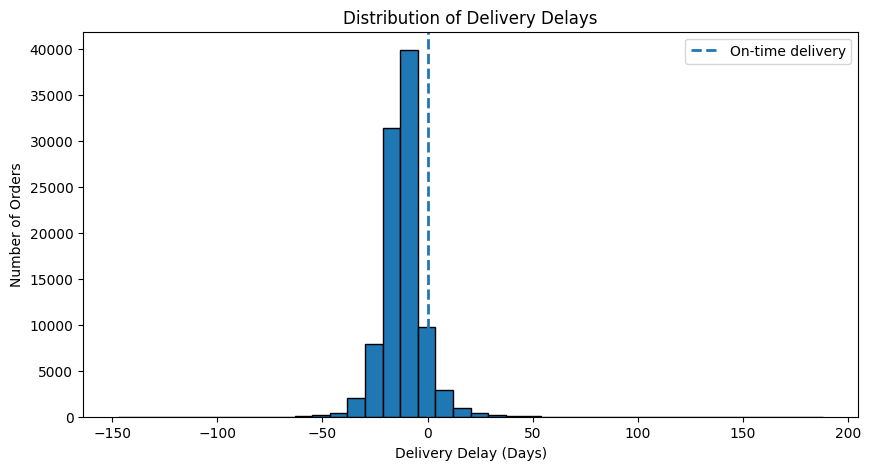

In [34]:
# Visualize the distribution of delivery delays

import matplotlib.pyplot as plt

delivery_delay_data = order_analysis["delivery_delay_days"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    delivery_delay_data,
    bins=40,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="On-time delivery"
)

plt.title("Distribution of Delivery Delays")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Number of Orders")
plt.legend()

plt.show()

**Findings**

The delivery delay distribution confirms that most orders were delivered earlier than their estimated delivery dates. The majority of observations are concentrated on the negative side of the distribution, with the highest concentration occurring between approximately -20 and 0 days.

Only a relatively small proportion of orders fall on the positive side of the distribution, indicating that late deliveries were less common. This finding is consistent with the calculated late delivery rate of 6.57%.

Overall, the delivery analysis suggests strong delivery performance, with most orders arriving before the estimated delivery date and relatively few orders experiencing delays.

### 3.4 Payment Method Distribution

Payment method distribution is examined to understand which payment methods are most frequently used by customers.

This analysis provides an overview of customer payment preferences and establishes a descriptive baseline before examining the relationship between payment methods and order outcomes in later sections.

In [35]:
payment_counts = (
    payments["payment_type"]
    .value_counts()
    .reset_index()
)

payment_counts.columns = ["Payment Method", "Number of Payment Records"]

payment_counts

,Payment Method,Number of Payment Records
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


In [36]:
fig = px.pie(
    payment_counts,
    names="Payment Method",
    values="Number of Payment Records",
    title="Payment Method Distribution",
    hole=0.35
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

**Findings**

- Credit card is by far the most frequently recorded payment method, accounting for approximately 74% of all payment records.
- Boleto is the second most frequently recorded payment method, representing approximately 19% of payment records.
- Voucher and debit card payments account for relatively small shares of the recorded payments.
- The `not_defined` category contains only three records and therefore has no meaningful impact on the overall distribution.
- Overall, the payment distribution indicates a strong preference for credit card payments in the recorded payment data.

### 3.5 Product Category Analysis

Product category analysis is conducted to understand the distribution of products across categories and identify which categories account for the largest share of orders.

This analysis provides an overview of category-level purchasing patterns before examining the relationship between product category, order value, and customer satisfaction in later sections.

In [37]:
# Analyze product category distribution

category_distribution = (
    products["product_category_name"]
    .value_counts(dropna=False)
    .reset_index()
)

category_distribution.columns = [
    "Product Category",
    "Product Count"
]

category_distribution.head(15)

,Product Category,Product Count
0,cama_mesa_banho,3029
1,esporte_lazer,2867
2,moveis_decoracao,2657
3,beleza_saude,2444
4,utilidades_domesticas,2335
5,automotivo,1900
6,informatica_acessorios,1639
7,brinquedos,1411
8,relogios_presentes,1329
9,telefonia,1134


In [38]:
# Check the number of product categories and missing category values

category_summary = pd.Series({
    "Total Product Categories": products["product_category_name"].nunique(),
    "Missing Category Values": products["product_category_name"].isna().sum(),
    "Missing Category Share (%)": products["product_category_name"].isna().mean() * 100
})

category_summary

,0
Total Product Categories,73.000000
Missing Category Values,610.000000
Missing Category Share (%),1.851234


In [39]:
# Analyze category distribution across purchased items

category_sales = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    ["product_category_name"]
    .value_counts()
    .reset_index()
)

category_sales.columns = [
    "Product Category",
    "Items Sold"
]

category_sales.head(15)

,Product Category,Items Sold
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


In [40]:
# Calculate the sales share of each product category

category_sales["Sales Share (%)"] = (
    category_sales["Items Sold"]
    / category_sales["Items Sold"].sum()
    * 100
)

category_sales.head(15)

,Product Category,Items Sold,Sales Share (%)
0,cama_mesa_banho,11115,10.009275
1,beleza_saude,9670,8.708025
2,esporte_lazer,8641,7.781390
3,moveis_decoracao,8334,7.504930
4,informatica_acessorios,7827,7.048367
5,utilidades_domesticas,6964,6.271218
6,relogios_presentes,5991,5.395013
7,telefonia,4545,4.092862
8,ferramentas_jardim,4347,3.914559
9,automotivo,4235,3.813701


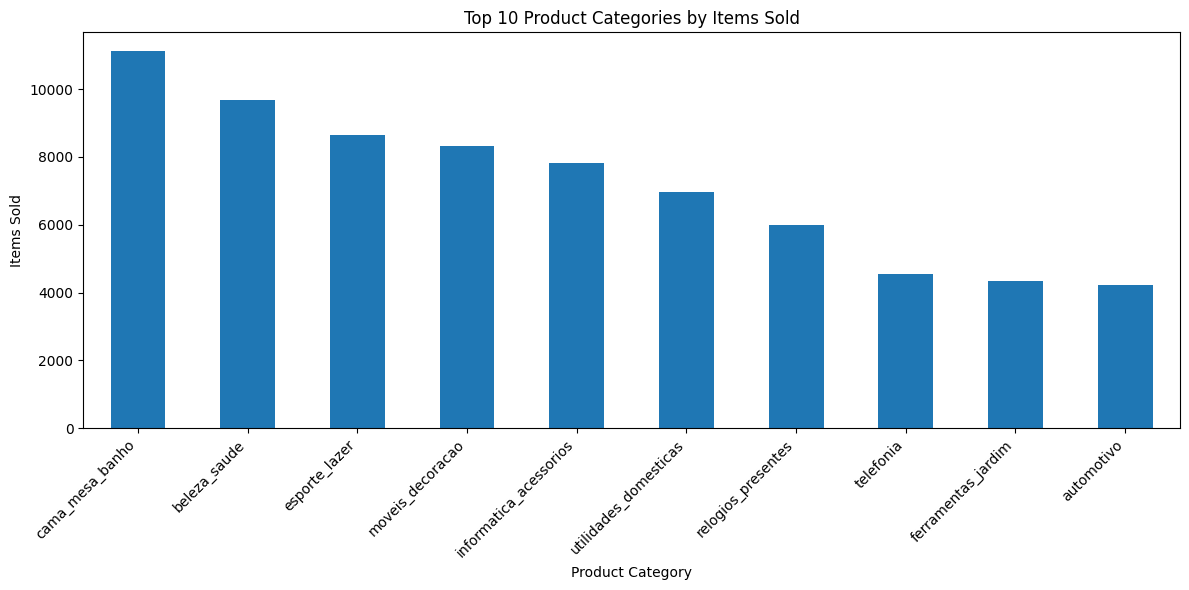

In [41]:
# Visualize the top 10 product categories by sales volume

top_10_categories = category_sales.head(10)

top_10_categories.plot(
    x="Product Category",
    y="Items Sold",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Product Category")
plt.ylabel("Items Sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Findings**

The product category analysis shows that sales are distributed across a wide range of product categories, with 73 distinct categories identified in the dataset.

The `cama_mesa_banho` category has the highest sales volume, with 11,115 items sold, followed by `beleza_saude` with 9,670 items and `esporte_lazer` with 8,641 items. The top-selling categories therefore account for a substantial share of total item sales.

The sales distribution also shows that several categories perform strongly rather than sales being concentrated in a single category. This suggests that the platform serves diverse customer needs across multiple product segments.

From a business perspective, the highest-volume categories may represent important areas for inventory planning, promotional campaigns, and category-specific growth strategies.

### 3.6 Cargo Duration Analysis

Cargo duration is analyzed to understand how long orders take to move through the delivery process and whether delivery duration varies across orders.

This analysis focuses on the time between the relevant order and delivery stages, providing an overview of typical delivery duration and identifying potential variation in the delivery process.

Understanding delivery duration is important for evaluating operational performance and its potential relationship with customer satisfaction.

In [42]:
# Descriptive statistics for delivery duration

order_analysis["delivery_days"].describe()

,delivery_days
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


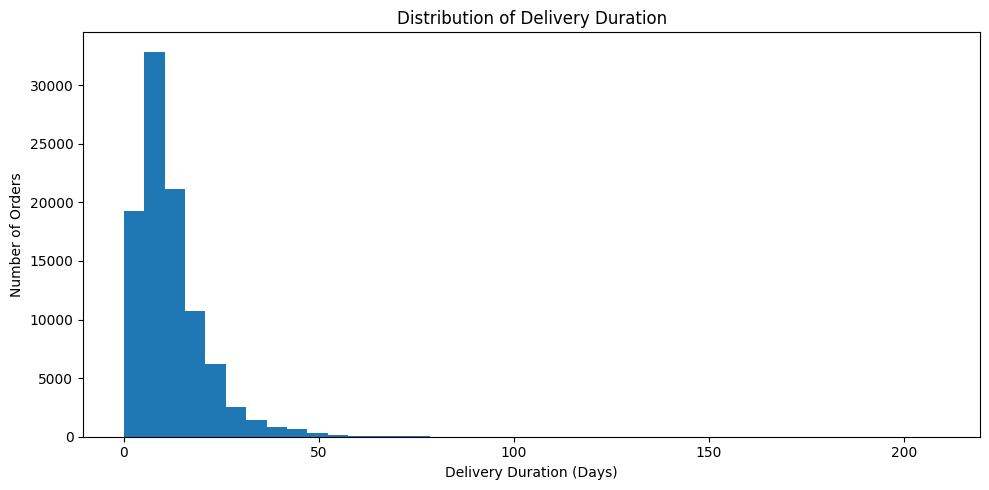

In [43]:
# Visualize the distribution of delivery duration

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    order_analysis["delivery_days"].dropna(),
    bins=40
)

plt.title("Distribution of Delivery Duration")
plt.xlabel("Delivery Duration (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [44]:
# Analyze typical and extended delivery durations

delivery_duration_summary = pd.Series({
    "Average Delivery Days": order_analysis["delivery_days"].mean(),
    "Median Delivery Days": order_analysis["delivery_days"].median(),
    "Orders Delivered Within 7 Days (%)": (
        (order_analysis["delivery_days"] <= 7).mean() * 100
    ),
    "Orders Delivered Within 14 Days (%)": (
        (order_analysis["delivery_days"] <= 14).mean() * 100
    ),
    "Orders Taking More Than 30 Days (%)": (
        (order_analysis["delivery_days"] > 30).mean() * 100
    )
})

delivery_duration_summary

,0
Average Delivery Days,12.094086
Median Delivery Days,10.000000
Orders Delivered Within 7 Days (%),33.887431
Orders Delivered Within 14 Days (%),70.490039
Orders Taking More Than 30 Days (%),4.141149


**Findings**

The delivery duration analysis shows that orders typically reach customers within a relatively short period. The average delivery duration is 12.09 days, while the median is 10 days, indicating that half of the orders are delivered within 10 days.

Approximately 33.89% of orders are delivered within 7 days, while 70.49% are delivered within 14 days. This suggests that most customers receive their orders within two weeks.

Only 4.14% of orders take more than 30 days to be delivered. However, the distribution is strongly right-skewed, with a small number of orders taking considerably longer than the typical delivery duration.

Overall, the findings indicate that delivery durations are generally concentrated within the first two weeks, although a small number of unusually long deliveries contribute to the extended right tail of the distribution.

### 3.7 Customer Satisfaction Analysis

Customer satisfaction is analyzed to understand how customers evaluated their purchasing experience. The analysis focuses on review scores provided after orders and examines the overall distribution of customer ratings.

This analysis aims to identify the most common satisfaction levels, assess the overall customer experience, and determine whether very low or very high ratings are concentrated in the dataset.

Understanding customer satisfaction is important for evaluating the overall quality of the e-commerce experience and for identifying potential areas for improvement.

In [45]:
# Customer satisfaction distribution

review_distribution = (
    order_analysis["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_distribution.columns = ["Review Score", "Order Count"]

review_distribution

,Review Score,Order Count
0,1.000000,11316
1,1.500000,8
2,2.000000,3125
3,2.500000,34
4,3.000000,8136
5,3.333333,1
6,3.500000,25
7,4.000000,19018
8,4.333333,1
9,4.500000,54


In [46]:
# Summarize overall customer satisfaction

satisfaction_summary = pd.Series({
    "Average Review Score": order_analysis["review_score"].mean(),
    "Median Review Score": order_analysis["review_score"].median(),
    "High Satisfaction (>= 4)": (order_analysis["review_score"] >= 4).mean() * 100,
    "Low Satisfaction (<= 2)": (order_analysis["review_score"] <= 2).mean() * 100
})

satisfaction_summary

,0
Average Review Score,4.086793
Median Review Score,5.000000
High Satisfaction (>= 4),76.455386
Low Satisfaction (<= 2),14.530224


In [47]:
# Group orders into customer satisfaction levels

satisfaction_levels = pd.cut(
    order_analysis["review_score"],
    bins=[-float("inf"), 2, 3, float("inf")],
    labels=["Low Satisfaction", "Neutral Satisfaction", "High Satisfaction"]
)

satisfaction_distribution = (
    satisfaction_levels
    .value_counts()
    .sort_index()
    .reset_index()
)

satisfaction_distribution.columns = ["Satisfaction Level", "Order Count"]

satisfaction_distribution["Share (%)"] = (
    satisfaction_distribution["Order Count"]
    / satisfaction_distribution["Order Count"].sum()
    * 100
)

satisfaction_distribution

,Satisfaction Level,Order Count,Share (%)
0,Low Satisfaction,14449,14.643317
1,Neutral Satisfaction,8170,8.279874
2,High Satisfaction,76054,77.076809


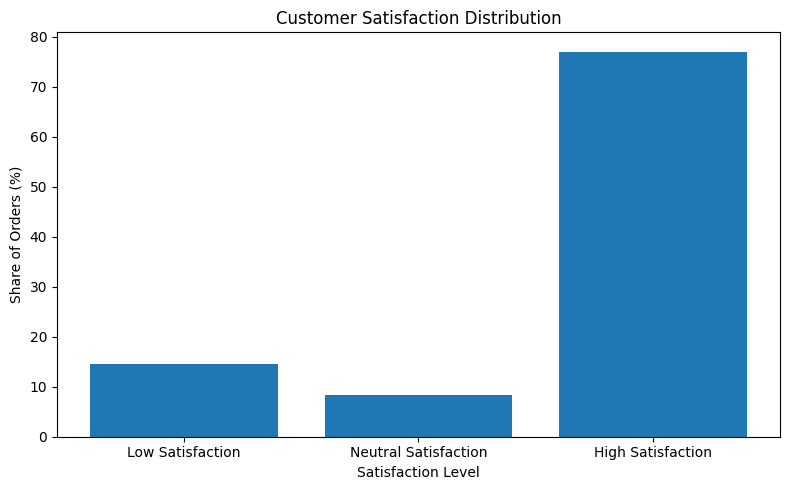

In [48]:
# Visualize customer satisfaction levels

plt.figure(figsize=(8, 5))

plt.bar(
    satisfaction_distribution["Satisfaction Level"],
    satisfaction_distribution["Share (%)"]
)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Level")
plt.ylabel("Share of Orders (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Findings**

The customer satisfaction analysis indicates that overall satisfaction is relatively high. Approximately 77.08% of orders fall into the high satisfaction category, while 8.28% are classified as neutral and 14.64% as low satisfaction.

The average review score is 4.09, while the median score is 5.00, indicating that positive reviews are concentrated around the upper end of the rating scale.

Overall, the findings suggest a generally positive customer experience, although the presence of a meaningful share of low-satisfaction orders indicates that there is still room to investigate the factors associated with negative customer feedback.

## 4. Correlation Analysis

### 4.1 Analysis Dataset Creation

### Purpose of the Analysis Dataset

To examine relationships between order characteristics, delivery performance, and customer satisfaction, a dedicated analysis dataset is prepared from the order-level analytical dataset and the relevant original tables.

The analysis focuses on the following variables:

- **Order Value** – the total monetary value of an order
- **Delivery Duration** – the number of days between order placement and delivery
- **Customer Satisfaction** – represented by the customer review score
- **Product Category** – used to examine differences in customer satisfaction across product groups
- **Payment Method** – used to examine differences in customer satisfaction across payment types

The order-level analytical dataset already contains the main numerical variables required for relationship analysis. Product category and payment method are not directly available in this dataset and will therefore be incorporated from the relevant source tables when required.

This approach keeps the analysis focused while maintaining consistency with the data preparation performed in the previous sections.

In [49]:
# Inspect the available variables in the order-level analytical dataset

order_analysis.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_state',
 'item_count',
 'product_value',
 'freight_value',
 'order_value',
 'payment_value',
 'payment_installments',
 'review_score',
 'delivery_days',
 'delivery_delay_days',
 'on_time_delivery']

In [50]:
# Create the core dataset for relationship analysis

correlation_data = order_analysis[
    [
        "order_id",
        "order_value",
        "delivery_days",
        "review_score"
    ]
].copy()

correlation_data.head()

,order_id,order_value,delivery_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,8.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,13.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,9.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,13.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,2.0,5.0


### 4.2 Order Price vs. Delivery Time

### Purpose of the Analysis

This analysis examines whether order value is associated with delivery duration.

Understanding this relationship can help determine whether higher-value orders experience different delivery times compared with lower-value orders.

The analysis uses **order value** as the measure of order price and **delivery duration** as the operational delivery metric. The relationship is evaluated using both a scatter plot and a correlation coefficient.

A correlation between two variables indicates the strength and direction of their association. However, correlation does not imply causation.

In [51]:
# Calculate the correlation between order value and delivery duration

order_value_delivery_corr = correlation_data[
    ["order_value", "delivery_days"]
].corr().iloc[0, 1]

order_value_delivery_corr

np.float64(0.06945779781152712)

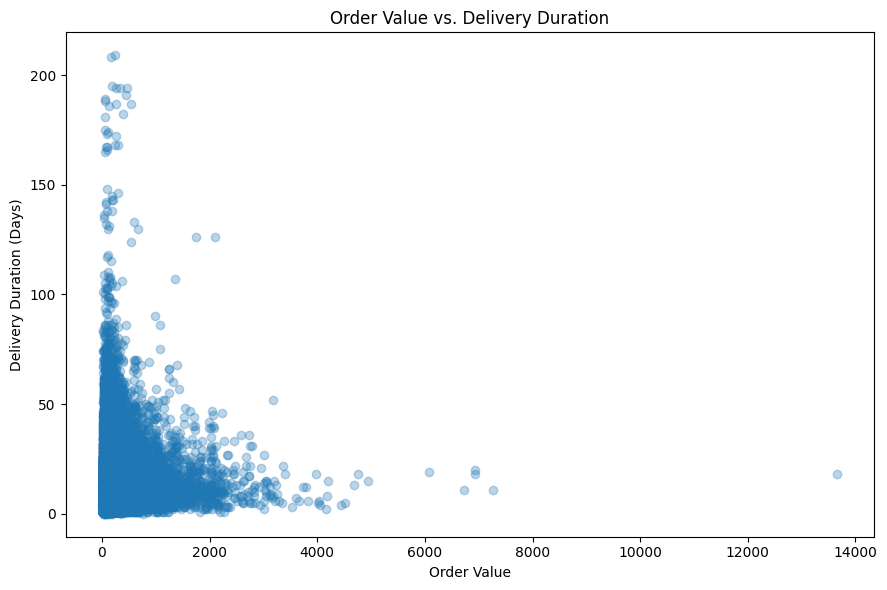

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    correlation_data["order_value"],
    correlation_data["delivery_days"],
    alpha=0.3
)

plt.title("Order Value vs. Delivery Duration")
plt.xlabel("Order Value")
plt.ylabel("Delivery Duration (Days)")

plt.tight_layout()
plt.show()

**Findings**

The analysis shows a very weak positive correlation between order value and delivery duration, with a Pearson correlation coefficient of approximately **0.069**.

The scatter plot does not reveal a clear linear relationship between the two variables. Most orders are concentrated at relatively low order values and shorter delivery durations, while a small number of observations extend to considerably higher order values or longer delivery times.

Although the correlation is positive, its magnitude is very small, indicating that **order value alone does not appear to be strongly associated with delivery duration** in this dataset.

Therefore, differences in delivery time are likely to be influenced by other operational or order-related factors rather than order value itself. This relationship should be interpreted as an association rather than a causal effect.

### 4.3 Order Price vs. Customer Satisfaction

### Purpose of the Analysis

This analysis examines whether order value is associated with customer satisfaction.

Understanding this relationship can help determine whether customers who place higher-value orders tend to report different levels of satisfaction compared with customers placing lower-value orders.

The analysis uses **order value** as the measure of order price and **review score** as the measure of customer satisfaction. The relationship is evaluated using both a scatter plot and a correlation coefficient.

A correlation between two variables indicates the strength and direction of their association. However, correlation does not imply causation.

In [53]:
# Calculate the correlation between order value and customer satisfaction

order_value_satisfaction_corr = correlation_data[
    ["order_value", "review_score"]
].corr().iloc[0, 1]

order_value_satisfaction_corr

np.float64(-0.04669000230294568)

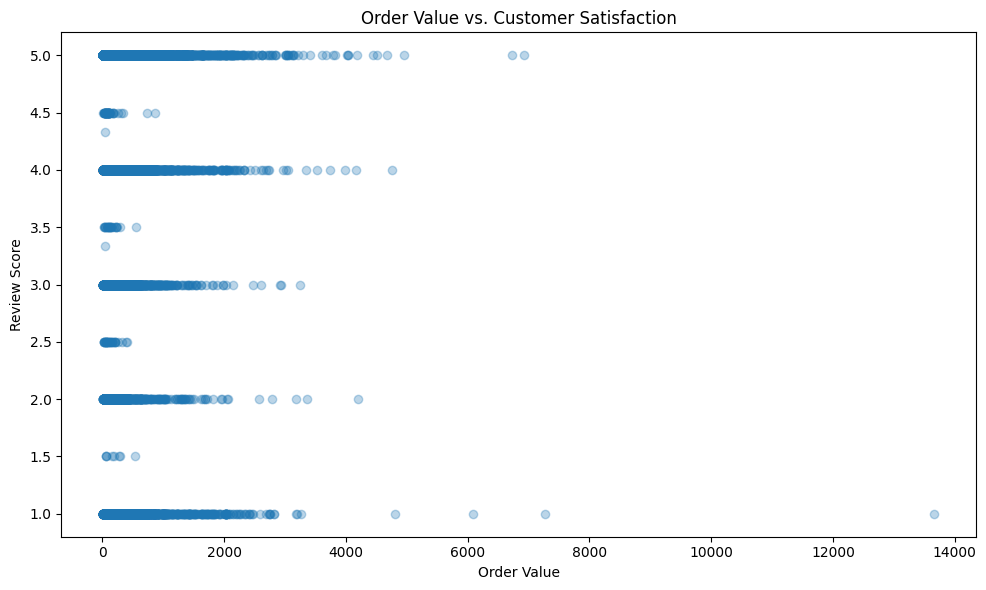

In [54]:
# Visualize the relationship between order value and customer satisfaction

plt.figure(figsize=(10, 6))

plt.scatter(
    correlation_data["order_value"],
    correlation_data["review_score"],
    alpha=0.3
)

plt.title("Order Value vs. Customer Satisfaction")
plt.xlabel("Order Value")
plt.ylabel("Review Score")

plt.tight_layout()
plt.show()

**Findings**

The analysis shows a very weak negative correlation between order value and customer satisfaction, with a Pearson correlation coefficient of approximately **-0.047**.

The scatter plot does not reveal a clear relationship between order value and review score. Customer ratings are distributed across different order values, with high and low review scores appearing throughout the range of order values.

The near-zero correlation indicates that **order value alone does not appear to be meaningfully associated with customer satisfaction** in this dataset.

This suggests that customers placing higher-value orders do not systematically report higher or lower satisfaction than customers placing lower-value orders. Other factors, such as delivery performance, product characteristics, or payment experience, may be more relevant to customer satisfaction.

As with all correlation analysis, this result indicates an association rather than a causal relationship.

### 4.4 Product Category vs. Customer Satisfaction

### Purpose of the Analysis

This analysis examines whether customer satisfaction differs across product categories.

Understanding differences in customer satisfaction between product categories can help identify categories that perform particularly well or poorly from the customer's perspective.

The analysis uses **product category** as the grouping variable and **review score** as the measure of customer satisfaction. Average review scores are compared across product categories to identify potential differences in customer experience.

Because product category is a categorical variable, the analysis focuses on comparing group-level satisfaction rather than calculating a correlation coefficient.

In [56]:
# Check which dataframe contains the product category variable

print("order_analysis columns:")
print(order_analysis.columns.tolist())

order_analysis columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_state', 'item_count', 'product_value', 'freight_value', 'order_value', 'payment_value', 'payment_installments', 'review_score', 'delivery_days', 'delivery_delay_days', 'on_time_delivery']


In [57]:
# Find the dataframe that contains the product category variable

category_columns = {}

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        matches = [
            col for col in obj.columns
            if "categor" in col.lower()
        ]

        if matches:
            category_columns[name] = matches

category_columns

{'products': ['product_category_name'],
 'category_distribution': ['Product Category'],
 '_37': ['Product Category'],
 'category_sales': ['Product Category'],
 '_39': ['Product Category'],
 '_40': ['Product Category'],
 'top_10_categories': ['Product Category']}

In [58]:
# Inspect the order-items dataset before linking products to orders

order_items.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [59]:
# Build an order-category dataset for customer satisfaction analysis

order_category_data = (
    order_items[["order_id", "product_id"]]
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .dropna(subset=["product_category_name"])
    .drop_duplicates(["order_id", "product_category_name"])
    .merge(
        order_analysis[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

order_category_data.head()

,order_id,product_id,product_category_name,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,5.0


In [60]:
# Calculate customer satisfaction by product category

category_satisfaction = (
    order_category_data
    .groupby("product_category_name")
    .agg(
        Average_Review_Score=("review_score", "mean"),
        Order_Count=("order_id", "nunique")
    )
    .sort_values("Average_Review_Score", ascending=False)
)

category_satisfaction.head(10)

,Average_Review_Score,Order_Count
product_category_name,,
cds_dvds_musicais,4.666667,12
fashion_roupa_infanto_juvenil,4.500000,8
livros_interesse_geral,4.462598,512
construcao_ferramentas_ferramentas,4.425532,97
livros_tecnicos,4.400778,260
flores,4.392857,29
alimentos_bebidas,4.382743,227
malas_acessorios,4.331068,1034
livros_importados,4.320755,53


In [61]:
# Focus on product categories with a sufficient number of orders

category_satisfaction_filtered = (
    category_satisfaction
    .query("Order_Count >= 100")
    .sort_values("Average_Review_Score", ascending=False)
)

category_satisfaction_filtered

,Average_Review_Score,Order_Count
product_category_name,,
livros_interesse_geral,4.462598,512
livros_tecnicos,4.400778,260
alimentos_bebidas,4.382743,227
malas_acessorios,4.331068,1034
alimentos,4.276404,450
papelaria,4.244662,2311
pet_shop,4.238095,1710
fashion_calcados,4.218220,240
perfumaria,4.203333,3162


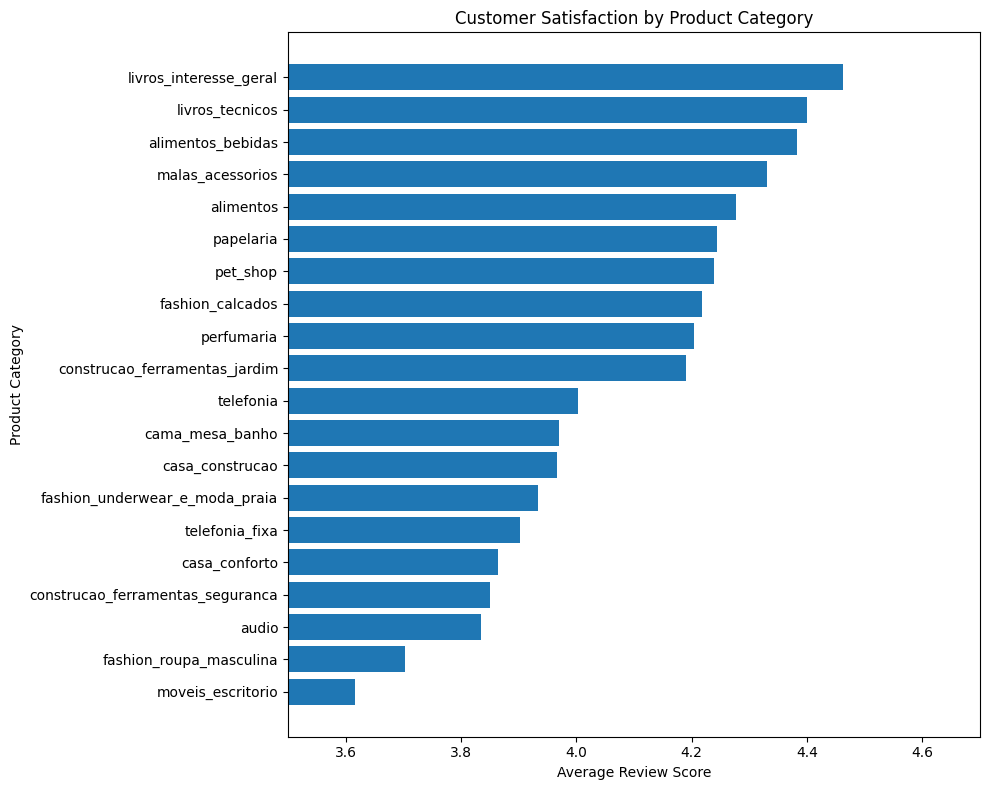

In [68]:
# Visualize the highest and lowest customer satisfaction by product category

top_10_categories = (
    category_satisfaction_filtered
    .sort_values("Average_Review_Score", ascending=False)
    .head(10)
)

bottom_10_categories = (
    category_satisfaction_filtered
    .sort_values("Average_Review_Score", ascending=True)
    .head(10)
)

plot_data = pd.concat([
    top_10_categories,
    bottom_10_categories
]).sort_values("Average_Review_Score")

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data.index,
    plot_data["Average_Review_Score"]
)

plt.xlabel("Average Review Score")
plt.ylabel("Product Category")
plt.title("Customer Satisfaction by Product Category")

plt.xlim(3.5, 4.7)
plt.tight_layout()

plt.show()

**Findings**

Customer satisfaction varies across product categories.

Among categories with at least 100 orders, `livros_interesse_geral` has the highest average review score (4.46), followed by `livros_tecnicos` (4.40) and `alimentos_bebidas` (4.38).

On the other hand, `moveis_escritorio` has the lowest average review score (3.62), followed by `fashion_roupa_masculina` (3.70) and `audio` (3.83).

Overall, the results suggest that customer satisfaction differs across product categories. However, these descriptive differences alone do not establish whether the differences are statistically significant. Statistical testing is therefore required before drawing stronger conclusions about the relationship between product category and customer satisfaction.

### 4.5 Payment Method vs. Customer Satisfaction

### Purpose of the Analysis

This analysis examines whether customer satisfaction differs across payment methods.

Understanding the relationship between payment method and customer satisfaction can help identify whether certain payment methods are associated with better or worse customer experiences.

The analysis uses **payment method** as the grouping variable and **review score** as the measure of customer satisfaction. Because an order can contain more than one payment method, the payment method with the highest payment value is assigned as the **primary payment method** for each order.

The analysis first examines the available payment methods and identifies orders with multiple payment methods. It then assigns a primary payment method to each order so that customer satisfaction can be compared consistently across payment groups.

Because payment method is a categorical variable, the analysis focuses on comparing customer satisfaction between payment groups rather than calculating a correlation coefficient.

In [62]:
# Inspect payment-related variables across available dataframes

payment_columns = {}

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        matches = [
            col for col in obj.columns
            if "payment" in col.lower()
        ]

        if matches:
            payment_columns[name] = matches

payment_columns

{'payments': ['payment_sequential',
  'payment_type',
  'payment_installments',
  'payment_value'],
 'missing_summary': ['Payments'],
 '_7': ['Payments'],
 'payments_summary': ['payment_value', 'payment_installments'],
 '_11': ['payment_value', 'payment_installments'],
 'order_analysis': ['payment_value', 'payment_installments'],
 'high_value_orders': ['payment_value', 'payment_installments'],
 'payment_counts': ['Payment Method', 'Number of Payment Records'],
 '_35': ['Payment Method', 'Number of Payment Records']}

In [63]:
# Inspect payment methods and payment records

print("Payment methods:")
print(payments["payment_type"].value_counts())

print("\nNumber of unique orders:")
print(payments["order_id"].nunique())

print("\nTotal payment records:")
print(len(payments))

Payment methods:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Number of unique orders:
99440

Total payment records:
103886


In [64]:
# Check whether orders have multiple payment methods

payment_method_per_order = (
    payments.groupby("order_id")["payment_type"]
    .nunique()
)

print("Orders with more than one payment method:")
print((payment_method_per_order > 1).sum())

print("\nMaximum number of payment methods in a single order:")
print(payment_method_per_order.max())

Orders with more than one payment method:
2246

Maximum number of payment methods in a single order:
2


In [65]:
# Inspect orders that use multiple payment methods

multiple_payment_orders = payment_method_per_order[
    payment_method_per_order > 1
]

print("Number of orders with multiple payment methods:")
print(len(multiple_payment_orders))

print("\nPayment method combinations for multi-payment orders:")

multi_payment_details = (
    payments[payments["order_id"].isin(multiple_payment_orders.index)]
    .groupby("order_id")["payment_type"]
    .apply(lambda x: " + ".join(sorted(x.unique())))
    .value_counts()
)

multi_payment_details

Number of orders with multiple payment methods:
2246

Payment method combinations for multi-payment orders:


,count
payment_type,
credit_card + voucher,2245
credit_card + debit_card,1


In [66]:
# Assign the primary payment method to each order
# based on the payment method with the highest payment value

primary_payment = (
    payments
    .sort_values(["order_id", "payment_value"], ascending=[True, False])
    .drop_duplicates("order_id")
    [["order_id", "payment_type", "payment_value"]]
    .copy()
)

primary_payment.head()

,order_id,payment_type,payment_value
85283,00010242fe8c5a6d1ba2dd792cb16214,credit_card,72.19
2499,00018f77f2f0320c557190d7a144bdd3,credit_card,259.83
12393,000229ec398224ef6ca0657da4fc703e,credit_card,216.87
32971,00024acbcdf0a6daa1e931b038114c75,credit_card,25.78
98711,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card,218.04


In [69]:
# Link primary payment method with customer satisfaction

payment_satisfaction_data = (
    primary_payment
    .merge(
        order_analysis[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

payment_satisfaction_data.head()

,order_id,payment_type,payment_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,credit_card,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,credit_card,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,credit_card,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card,218.04,5.0


In [70]:
# Compare customer satisfaction across payment methods

payment_satisfaction_summary = (
    payment_satisfaction_data
    .groupby("payment_type")["review_score"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

payment_satisfaction_summary

,mean,count
payment_type,,
debit_card,4.169954,1521
credit_card,4.088537,74391
boleto,4.087136,19636
voucher,4.005874,3121
not_defined,1.666667,3


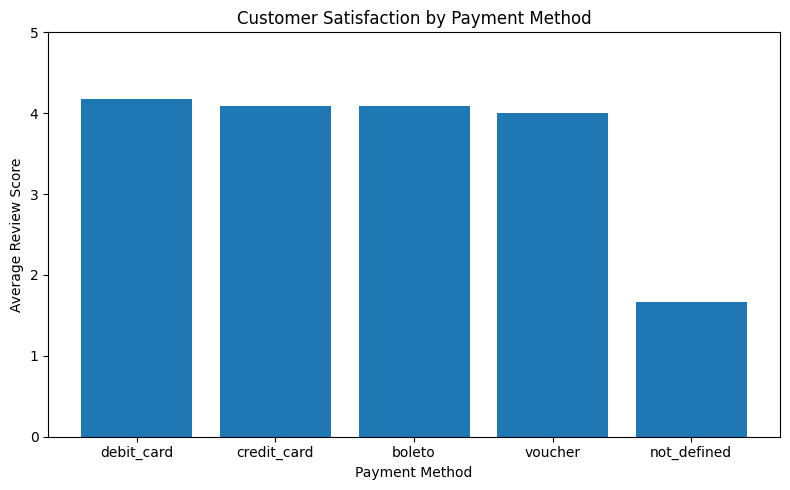

In [71]:
# Visualize customer satisfaction by payment method

plt.figure(figsize=(8, 5))

plt.bar(
    payment_satisfaction_summary.index,
    payment_satisfaction_summary["mean"]
)

plt.title("Customer Satisfaction by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Findings**

Customer satisfaction is relatively similar across the main payment methods.

Among payment methods with sufficient observations, debit card has the highest average review score (4.17), followed by credit card (4.09), boleto (4.09), and voucher (4.01).

The `not_defined` category has a much lower average review score (1.67), but it is based on only 3 records and is therefore not considered representative.

Overall, the descriptive results suggest that customer satisfaction does not vary substantially across the main payment methods. However, these differences alone do not establish whether payment method and customer satisfaction are statistically significantly related. Statistical testing is required before drawing stronger conclusions.

### 4.6 Delivery Duration vs. Customer Satisfaction

### Purpose of the Analysis

This analysis examines whether delivery duration is associated with customer satisfaction.

The purpose is to determine whether longer delivery times are associated with lower customer review scores and to identify potential patterns between delivery performance and customer satisfaction.

In [72]:
# Inspect delivery-related variables

delivery_columns = {}

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        matches = [
            col for col in obj.columns
            if any(
                word in col.lower()
                for word in ["delivery", "delivered", "estimated"]
            )
        ]

        if matches:
            delivery_columns[name] = matches

delivery_columns

{'orders': ['order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date'],
 'order_analysis': ['order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date',
  'delivery_days',
  'delivery_delay_days',
  'on_time_delivery'],
 '_15': ['delivery_days', 'delivery_delay_days', 'on_time_delivery'],
 'high_value_orders': ['order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date',
  'delivery_days',
  'delivery_delay_days',
  'on_time_delivery'],
 'correlation_data': ['delivery_days'],
 '_50': ['delivery_days']}

In [73]:
# Compare delivery duration with customer satisfaction

delivery_satisfaction_data = (
    order_analysis[["delivery_days", "review_score"]]
    .dropna()
)

delivery_satisfaction_data.head()

,delivery_days,review_score
0,8.0,4.0
1,13.0,4.0
2,9.0,5.0
3,13.0,5.0
4,2.0,5.0


In [74]:
# Measure the relationship between delivery duration and customer satisfaction

delivery_satisfaction_corr = (
    delivery_satisfaction_data["delivery_days"]
    .corr(delivery_satisfaction_data["review_score"])
)

print("Correlation between delivery duration and customer satisfaction:")
print(round(delivery_satisfaction_corr, 3))

Correlation between delivery duration and customer satisfaction:
-0.334


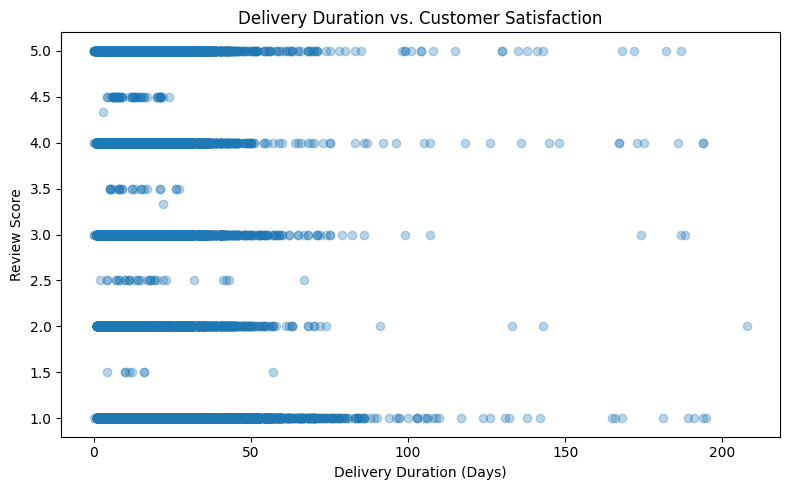

In [75]:
# Visualize the relationship between delivery duration and customer satisfaction

plt.figure(figsize=(8, 5))

plt.scatter(
    delivery_satisfaction_data["delivery_days"],
    delivery_satisfaction_data["review_score"],
    alpha=0.3
)

plt.title("Delivery Duration vs. Customer Satisfaction")
plt.xlabel("Delivery Duration (Days)")
plt.ylabel("Review Score")

plt.tight_layout()
plt.show()

**Findings**

There is a negative relationship between delivery duration and customer satisfaction.

The correlation coefficient is -0.334, indicating a weak-to-moderate negative association. This suggests that longer delivery times tend to be associated with lower customer review scores.

The scatter plot also shows that lower review scores are more frequently observed at longer delivery durations. However, the relationship is not strong enough to conclude that delivery duration alone determines customer satisfaction.

Overall, the results suggest that delivery performance may be an important factor in customer satisfaction. Statistical testing is required to determine whether this observed relationship is statistically significant.

## 5. Hypothesis Testing

### Purpose of the Analysis

The purpose of this section is to statistically test the relationships identified in the descriptive and correlation analyses.

The following hypotheses will be tested:

1. Whether customer satisfaction differs significantly across product categories.
2. Whether customer satisfaction differs significantly across payment methods.
3. Whether delivery duration is significantly associated with customer satisfaction.

A significance level of 0.05 will be used for all hypothesis tests.

### 5.1 Product Category vs. Customer Satisfaction

**H₀ (Null Hypothesis):** Mean customer satisfaction is equal across product categories.

**H₁ (Alternative Hypothesis):** Mean customer satisfaction differs across at least one product category.

The one-way ANOVA test is used because product category is a categorical variable with multiple independent groups, while customer satisfaction is measured using the review score.

In [79]:
# Prepare data for testing the relationship between
# product category and customer satisfaction

category_test_data = (
    order_category_data[["product_category_name", "review_score"]]
    .dropna()
)

category_counts = category_test_data["product_category_name"].value_counts()

valid_categories = category_counts[category_counts >= 100].index

category_test_data = category_test_data[
    category_test_data["product_category_name"].isin(valid_categories)
]

print("Number of product categories tested:")
print(category_test_data["product_category_name"].nunique())

print("\nNumber of observations:")
print(len(category_test_data))

Number of product categories tested:
51

Number of observations:
96421


In [80]:
# Test whether customer satisfaction differs significantly
# across product categories

from scipy.stats import f_oneway

category_groups = [
    group["review_score"].values
    for _, group in category_test_data.groupby("product_category_name")
]

anova_stat, anova_p = f_oneway(*category_groups)

print("One-Way ANOVA results:")
print("F-statistic:", round(anova_stat, 3))
print("p-value:", anova_p)

One-Way ANOVA results:
F-statistic: 13.359
p-value: 1.5820768894231439e-108


**Hypotheses**

- **H₀ (Null Hypothesis):** Mean customer satisfaction is equal across product categories.
- **H₁ (Alternative Hypothesis):** Mean customer satisfaction differs across at least one product category.

**Test Result**

A one-way ANOVA was conducted to examine whether customer satisfaction differs across product categories.

- **F-statistic:** 13.359
- **p-value:** < 0.001

Since the p-value is below the 0.05 significance level, the null hypothesis is rejected.

**Interpretation**

The results indicate that customer satisfaction differs significantly across product categories.

However, ANOVA only indicates that at least one category differs from another; it does not identify which specific categories are significantly different. A post-hoc test would be required for pairwise comparisons.

### 5.2 Payment Method vs. Customer Satisfaction

**H₀ (Null Hypothesis):** Customer satisfaction does not differ significantly across payment methods.

**H₁ (Alternative Hypothesis):** Customer satisfaction differs significantly across at least one payment method.

The Kruskal–Wallis H test is used because payment method is a categorical variable with multiple independent groups, while review score is an ordinal measure of customer satisfaction.

In [81]:
# Prepare data for the payment method hypothesis test

payment_test_data = (
    payment_satisfaction_data[["payment_type", "review_score"]]
    .dropna()
)

payment_counts = payment_test_data["payment_type"].value_counts()

valid_payment_methods = payment_counts[payment_counts >= 100].index

payment_test_data = payment_test_data[
    payment_test_data["payment_type"].isin(valid_payment_methods)
]

print("Payment methods tested:")
print(payment_test_data["payment_type"].unique())

print("\nNumber of observations:")
print(len(payment_test_data))

Payment methods tested:
['credit_card' 'boleto' 'debit_card' 'voucher']

Number of observations:
98669


In [82]:
# Perform the Kruskal–Wallis H test

from scipy.stats import kruskal

payment_groups = [
    group["review_score"].values
    for _, group in payment_test_data.groupby("payment_type")
]

kruskal_stat, kruskal_p = kruskal(*payment_groups)

print("Kruskal–Wallis H test results:")
print("H-statistic:", round(kruskal_stat, 3))
print("p-value:", kruskal_p)

Kruskal–Wallis H test results:
H-statistic: 14.867
p-value: 0.0019341483957716614


**Hypotheses**

- **H₀ (Null Hypothesis):** Customer satisfaction is distributed equally across payment methods.
- **H₁ (Alternative Hypothesis):** Customer satisfaction is distributed differently across at least one payment method.

**Test Result**

A Kruskal–Wallis H test was conducted to examine whether customer satisfaction differs across payment methods.

- **H-statistic:** 14.867
- **p-value:** 0.0019

Since the p-value is below the 0.05 significance level, the null hypothesis is rejected.

**Interpretation**

The results indicate that customer satisfaction differs significantly across payment methods.

However, the Kruskal–Wallis test only indicates that at least one payment method differs from another; it does not identify which specific payment methods are significantly different. A post-hoc test would be required for pairwise comparisons.

### 5.3 Delivery Duration vs. Customer Satisfaction

**H₀ (Null Hypothesis):** There is no significant association between delivery duration and customer satisfaction.

**H₁ (Alternative Hypothesis):** There is a significant association between delivery duration and customer satisfaction.

The Spearman rank correlation test is used because delivery duration is a continuous variable, while review score is an ordinal measure of customer satisfaction.

In [83]:
# Test whether delivery duration is significantly associated
# with customer satisfaction

from scipy.stats import spearmanr

delivery_test_data = (
    order_analysis[["delivery_days", "review_score"]]
    .dropna()
)

spearman_stat, spearman_p = spearmanr(
    delivery_test_data["delivery_days"],
    delivery_test_data["review_score"]
)

print("Spearman rank correlation test results:")
print("Correlation coefficient:", round(spearman_stat, 3))
print("p-value:", spearman_p)

Spearman rank correlation test results:
Correlation coefficient: -0.235
p-value: 0.0


**Hypotheses**

- **H₀ (Null Hypothesis):** There is no significant association between delivery duration and customer satisfaction.
- **H₁ (Alternative Hypothesis):** There is a significant association between delivery duration and customer satisfaction.

**Test Result**

A Spearman rank correlation test was conducted to examine whether delivery duration is significantly associated with customer satisfaction.

- **Correlation coefficient:** -0.235
- **p-value:** < 0.001

Since the p-value is below the 0.05 significance level, the null hypothesis is rejected.

**Interpretation**

The results indicate that there is a statistically significant negative association between delivery duration and customer satisfaction.

The correlation coefficient of -0.235 indicates a weak negative relationship, suggesting that longer delivery durations tend to be associated with lower customer satisfaction.

However, the relatively weak correlation indicates that delivery duration alone does not fully explain differences in customer satisfaction.

## 6. Results Visualization & Interpretation

### 6.1 Product Category vs. Customer Satisfaction

This visualization compares average customer satisfaction across product categories. The analysis focuses on categories with at least 100 observations to ensure that the comparison is based on sufficiently represented groups.

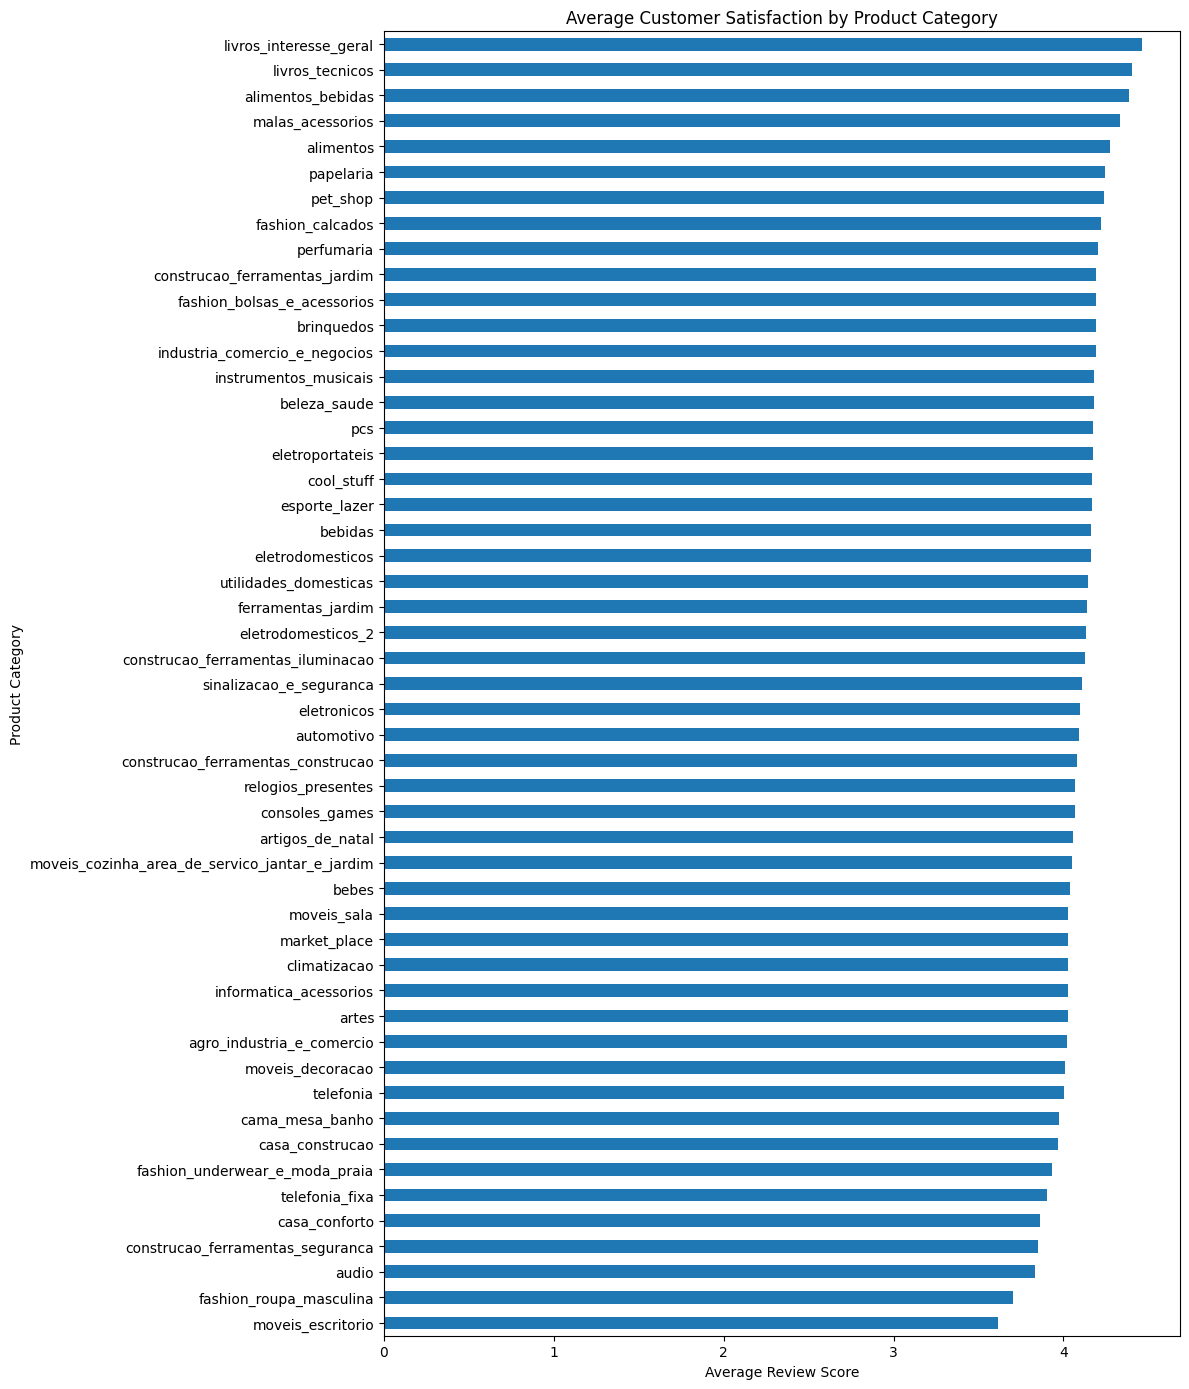

In [85]:
# Visualize average customer satisfaction across product categories

category_satisfaction_summary = (
    category_test_data
    .groupby("product_category_name")["review_score"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 14))

category_satisfaction_summary.plot(kind="barh")

plt.title("Average Customer Satisfaction by Product Category")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

**Findings**

Customer satisfaction varies across product categories, although the differences in average review scores are relatively moderate.

The highest average satisfaction is observed in `livros_interesse_geral`, while `moveis_escritorio` has the lowest average review score among the categories included in the analysis.

Overall, most product categories have average review scores above 3.5, with many categories clustered around 4.0–4.4.

The visualization shows that some product categories receive consistently higher customer satisfaction scores than others. This observation is consistent with the hypothesis testing results, which indicated a statistically significant difference in customer satisfaction across product categories.

However, the chart describes differences in average satisfaction and does not identify which specific category pairs differ significantly. Post-hoc pairwise testing would be required to determine this.

### 6.2 Payment Method vs. Customer Satisfaction

This section examines whether average customer satisfaction varies across the main payment methods.

The analysis focuses on payment methods with sufficient observations to provide more representative comparisons.

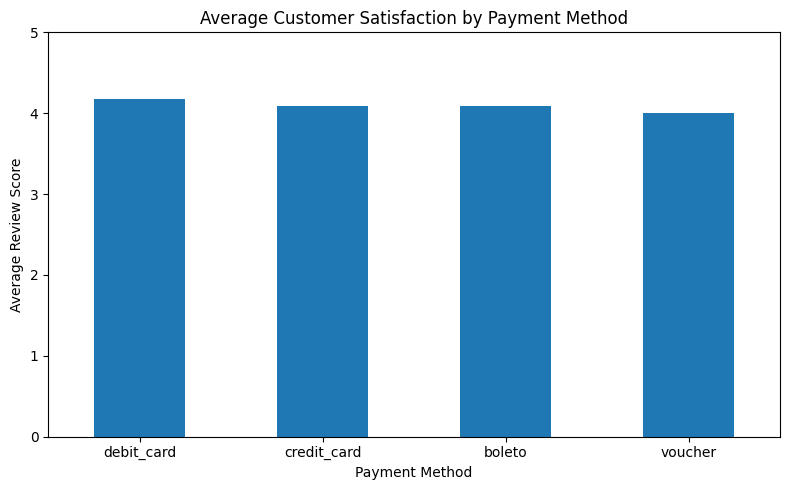

In [86]:
# Compare customer satisfaction across payment methods

payment_satisfaction = (
    payment_test_data
    .groupby("payment_type")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

payment_satisfaction.plot(kind="bar")

plt.title("Average Customer Satisfaction by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Findings**

Customer satisfaction is relatively similar across the main payment methods.

Among the payment methods included in the analysis, debit card has the highest average review score (4.17), followed by credit card (4.09), boleto (4.09), and voucher (4.01).

The differences between these payment methods are relatively small, suggesting that payment method may not have a substantial practical effect on customer satisfaction.

This observation is consistent with the descriptive analysis. However, the visual differences alone do not establish whether payment method and customer satisfaction are statistically significantly related. The hypothesis test results should be considered before drawing a final conclusion.

### 6.3 Delivery Duration vs. Customer Satisfaction

This section examines the relationship between delivery duration and customer satisfaction.

A scatter plot is used to visualize whether longer delivery times tend to be associated with lower customer review scores.

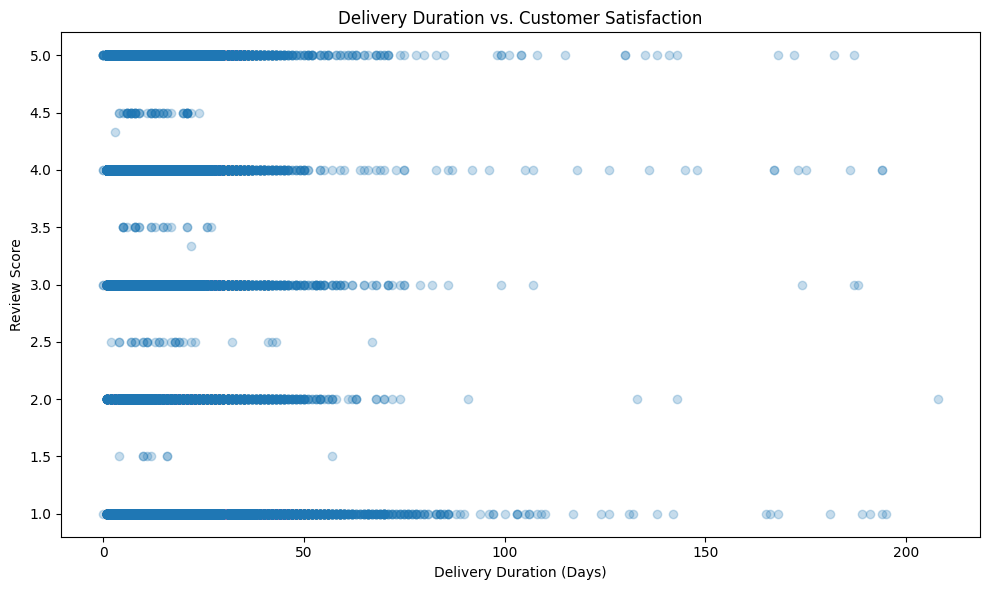

In [87]:
# Visualize the relationship between delivery duration and customer satisfaction

plt.figure(figsize=(10, 6))

plt.scatter(
    delivery_test_data["delivery_days"],
    delivery_test_data["review_score"],
    alpha=0.25
)

plt.title("Delivery Duration vs. Customer Satisfaction")
plt.xlabel("Delivery Duration (Days)")
plt.ylabel("Review Score")

plt.tight_layout()
plt.show()

**Findings**

There is a negative relationship between delivery duration and customer satisfaction.

The scatter plot shows that lower review scores are more frequently observed at longer delivery durations. This suggests that longer delivery times tend to be associated with lower customer satisfaction.

The relationship is relatively weak, meaning that delivery duration alone does not fully explain differences in customer satisfaction.

This observation is consistent with the Spearman correlation test, which found a statistically significant negative association between delivery duration and customer satisfaction (correlation coefficient = -0.235, p < 0.001).

Overall, the results suggest that delivery performance may be an important factor in customer satisfaction, although other factors are also likely to contribute.

## 7. Summary & Conclusions

This analysis examined customer satisfaction in the Olist e-commerce marketplace using product category, payment method, and delivery duration as key factors.

The analysis combined descriptive statistics, data visualization, correlation analysis, and hypothesis testing to identify patterns in customer satisfaction and evaluate whether the observed relationships were statistically significant.

### Key Findings

- **Product category:** Customer satisfaction differs significantly across product categories. The one-way ANOVA test resulted in an F-statistic of 13.359 with a p-value below 0.001. The visualization also shows moderate differences in average review scores across categories. However, the analysis does not identify which specific category pairs differ significantly; post-hoc testing would be required for pairwise comparisons.

- **Payment method:** Customer satisfaction differs significantly across payment methods according to the Kruskal–Wallis H test (H = 14.867, p = 0.0019). However, the average review scores are relatively close to each other, ranging from approximately 4.01 to 4.17. This suggests that although the difference is statistically significant, the practical difference in average satisfaction between payment methods appears relatively small.

- **Delivery duration:** Delivery duration has a statistically significant negative association with customer satisfaction. The Spearman correlation coefficient is -0.235 (p < 0.001), indicating that longer delivery durations tend to be associated with lower customer satisfaction. However, the relationship is relatively weak, suggesting that delivery duration alone does not fully explain differences in customer satisfaction.

### Overall Conclusion

The findings suggest that customer satisfaction in the Olist marketplace is associated with several aspects of the purchasing and delivery experience.

Product category shows statistically significant differences in customer satisfaction, while payment method also shows a statistically significant but relatively small difference. Delivery duration has a weak but statistically significant negative relationship with customer satisfaction.

Overall, the results indicate that customer satisfaction should not be explained by a single factor. Product characteristics, payment experience, delivery performance, and other unobserved factors may jointly contribute to customers' evaluations of their shopping experience.

### Limitations

This analysis focuses on associations and group differences and therefore does not establish causal relationships.

The hypothesis tests identify statistically significant differences or associations but do not explain their underlying causes. In addition, the product category and payment method analyses do not include post-hoc pairwise tests, so the specific groups responsible for the observed differences cannot be identified.

Future analysis could extend this work by applying post-hoc tests, examining additional customer and order characteristics, and developing predictive models to better understand the factors associated with customer satisfaction.